# Welcome to the tutorial on BMS symmetries and black hole perturbations!

Today we'll be covering, from a relatively zoomed out perspective:
* what the BMS symmetries are,
* how one can use them to write the sources of the gravitational wave strain in terms of BMS charges and fluxes,
* how to fit quasi-normal modes to NR waveforms,
* how to fit quasi-normal modes to LVK observations.
  
So, without further ado, let's get started!

If you're working with `uv` or with `conda` and have the corresponding environment activated, then you should have the packages required for this notebook installed.

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    !apt-get update -qq
    !apt-get install -y -qq texlive-latex-base texlive-latex-recommended texlive-latex-extra dvipng ghostscript cm-super
   
    import os
    import shutil
    if not (os.path.exists('requirements.txt') and os.path.exists('images')): 
        !wget https://github.com/keefemitman/ResearchTutorials/archive/main.zip
        !unzip main.zip
        for item in os.listdir('ResearchTutorials-main'):
            if not os.path.exists(item):
              shutil.move(f'ResearchTutorials-main/{item}', './')
        os.system('rm main.zip')
        os.system('rm -r ResearchTutorials-main')
    try:
        os.system('rm -r sample_data')
    except:
        pass

    !pip install -r requirements.txt

### Let's download some data!

The files we're downloading are:
* the strain waveform
* and the five Weyl scalar files $\Psi_{0-4}$ (which should really be thought of as tensor components, not scalars

output by a Cauchy-characteristic evolution (CCE) code. Normally the Weyl scalars aren't included in the SXS catalog since CCE 
is a relatively new development, so we'll need to download them from the SXS Collaboration's mini-catalog. In the future though,
the SXS catalog will indeed contain such files as they are very useful for gravitational wave research.

The files we'll download correspond to a $q=1$, non-spinning system, but there are many other systems that you can examine.

In [2]:
from utils_downloads import download_extcce_simulation

Choose any of the alt names from [this SXS mini-catalog](https://data.black-holes.org/waveforms/extcce_catalog.html), but, again, we'll work with `q1_nospin` for now.

In [3]:
simulation = "q1_nospin" 
download_extcce_simulation(simulation);

Exists:  ./q1_nospin/r4Psi1OverM2_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/r4Psi1OverM2_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r2Psi3_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/r5Psi0OverM3_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/r5Psi0OverM3_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/metadata.json
Exists:  ./q1_nospin/rhOverM_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/rhOverM_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r2Psi3_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/rMPsi4_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/rMPsi4_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r3Psi2OverM_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r3Psi2OverM_BondiCce_R0292_CoM.h5


### Loading an ABD object

The strain and the Weyl scalars downloaded above provide all of the information needed to construct the asymptotic metric.

We can load all of them into a single object, known as a `AsymptoticBondiData` object, using the `scri` package via:

In [4]:
import os, h5py, scri
from scri.asymptotic_bondi_data.map_to_superrest_frame import MT_to_WM, WM_to_MT

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('paper.mplstyle')

# Colorblind friendly from Nichols
colors = [
    "#000000",
    "#0072B2",
    "#009E73",
    "#E69F00",
    "#CC79A7",
    "#56B4E9",
    "#F0E442",
    "#D55E00",
]
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=colors)

# widths for PRD/PRL
onecol_w_in = 3.4
twocol_w_in = 7.0625

In [5]:
path_to_simulation = f"{simulation}"

input_radius = [x.split("_R")[1][:4] for x in os.listdir(path_to_simulation) if "rhOverM" in x][0]

abd_raw = scri.SpEC.file_io.create_abd_from_h5(
    h=f"{path_to_simulation}/rhOverM_BondiCce_R{input_radius}_CoM.h5",
    Psi4=f"{path_to_simulation}/rMPsi4_BondiCce_R{input_radius}_CoM.h5",
    Psi3=f"{path_to_simulation}/r2Psi3_BondiCce_R{input_radius}_CoM.h5",
    Psi2=f"{path_to_simulation}/r3Psi2OverM_BondiCce_R{input_radius}_CoM.h5",
    Psi1=f"{path_to_simulation}/r4Psi1OverM2_BondiCce_R{input_radius}_CoM.h5",
    Psi0=f"{path_to_simulation}/r5Psi0OverM3_BondiCce_R{input_radius}_CoM.h5",
    file_format="RPXMB",
)
abd_raw.t -= abd_raw.t[np.argmax(MT_to_WM(2.0*abd_raw.sigma.bar.dot).norm())]

dt = 1.0
abd = abd_raw.interpolate(np.arange(abd_raw.t[0], abd_raw.t[-1] + dt, dt))

This object contains the strain and Weyl scalars as attributes, e.g., `abd.sigma` or `abd.psi2`. 

Note that `sigma` here is really the gravitational wave shear, but this is related to the strain $h$ via $h=2\bar{\sigma}$.

We can plot their content via

/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Gravitational wave shear')

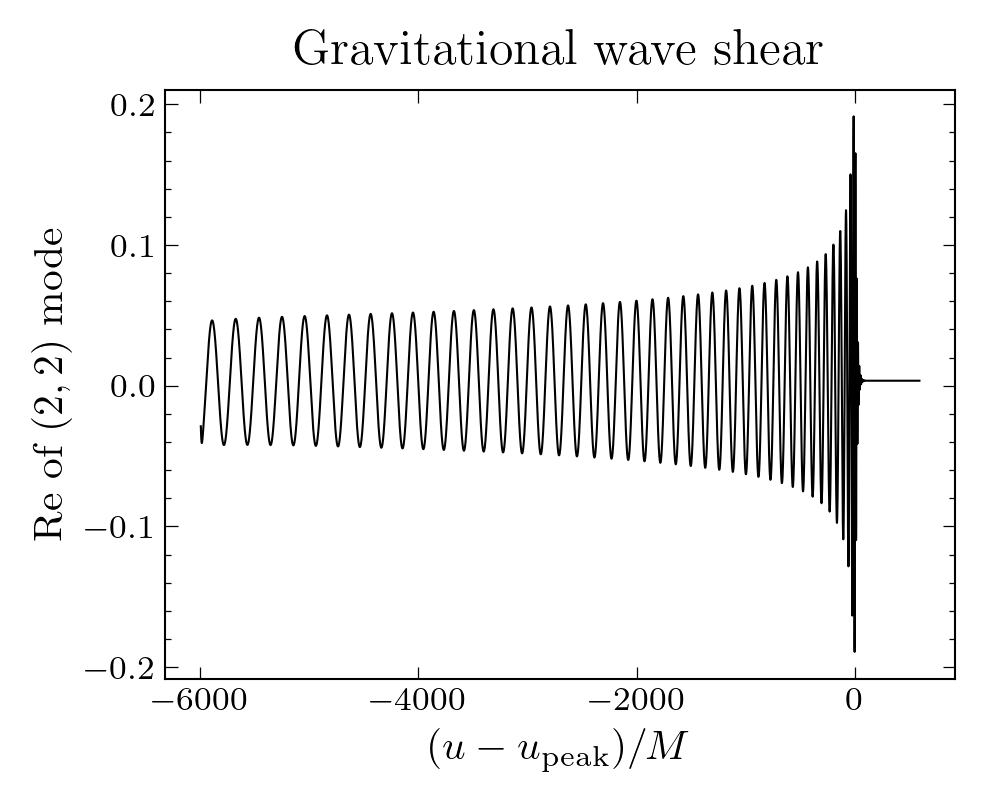

In [6]:
# strain; for the Weyl scalars just do, e.g., abd.psi2
L = 2; M = 2;
plt.plot(abd.sigma.t, abd.sigma[:,abd.h.index(L,M)])
plt.xlabel(r'$(u-u_{\mathrm{peak}})/M$')
plt.ylabel(r'Re of $(' + str(L) + ',' + str(M) + ')$ mode')
plt.title('Gravitational wave shear')

### A short trip to null infinity

At this point we'll want to pause and actually understand a bit more about null infinity and the gravitational content that we can extract there.

As outlined briefly in the other tutorial, in the early 60s, Bondi and Sachs showed that one can write down the metric describing asymptotically flat spacetimes as
\begin{align}
ds^2&=-Ue^{2\beta}du^2-2e^{2\beta}dudr\\
&\phantom{=.}+r^2\gamma_{AB}\left(dx^{A}-\mathcal{U}^{A}du\right)\left(dx^{B}-\mathcal{U}^{B}du\right)
\end{align}
where capital Latin indices range over the angles $(\theta,\phi)$, and we have the arbitrary functions $U$, $\beta$, $\mathcal{U}^{A}$, and $\gamma_{AB}$, each of which is a function of the coordinates $(u\equiv t-r,r,\theta,\phi)$.

Asymptotic flatness requires that as $r\rightarrow\infty$, we have
\begin{align}
U&\rightarrow1,\\
\beta&\rightarrow0,\\
\mathcal{U}^{A}&\rightarrow0,\\
\gamma_{AB}&\rightarrow\begin{pmatrix}1&0\\0&\sin^{2}\theta\end{pmatrix},
\end{align}
i.e., that we just asymptote to the usual Minkowski metric. With this understanding of the metric, one can then introduce Penrose's notion of conformal compactification, which naturally constructs the boundary "future null infinity $\mathcal{I}^{+}$" as the set of points $(u,\theta,\phi)$ obtained as $r\rightarrow\infty$. The reason why future null infinity is a useful boundary to construct is because when studying gravitational waves, it turns out that curves of constant $(r,\theta,\phi)$ are *nearly* geodesics, with $u$ *nearly* parametrizing the proper time. The only reason that they are not true geodesics is because there are $1/r$ corrections. Consequently, gravitational waves measured by a distant inertial observer can be approximated by gravitational waves studied at future null infinity. This is why we always aim to extract and model gravitational waves at future null infinity, because it's an excellent approximation for LIGO!

Now, just because we have these nice properties at future null infinity does *not* mean everything is all sunshine and roses. In fact, a somewhat obvious question that remains is, in this "Bondi frame" description, i.e., the asymptotic expansion we've imposed, **is there any remaining coordinate ambiguity that remains**? Intuitively we might expect that the answer would simply be the transformations that leave the usual Minkowski metric unchanged, i.e., the Poincaré group. However, this intuition turns out to be only *nearly* correct. Instead, it turns out that the symmetry group is a *much* larger group known as the BMS group, in which the usual spacetime translations are promoted to an infinite dimensional set of *supertranslations*.

Technically, the way one derives this is by solving Killing's equation, i.e.,
\begin{align}
\mathcal{L}_{\vec{\xi}}g_{\mu\nu}=0,
\end{align}
with respect to the fall-off conditions implied by the earlier equation. In doing so, one finds that the vector field $\vec{\xi}$ which preserves the asymptotic structure of the metric is
\begin{align}
\vec{\xi}=\left[\alpha\left(\theta^{A}\right)+\frac{1}{2}uD_{A}Y^{A}\left(\theta^{B}\right)\right]\partial_{u}+Y^{A}\left(\theta_{B}\right)\partial_{A}
\end{align}
where $\alpha(\theta^{A})$ is the function parametrizing supertranslations (note that it is an arbitrary smooth function on the two-sphere) and $Y^{A}$ is a vector field, which when written in terms of its "electric" and "magnetic" components (think divergence and curl) as $Y^{a}=D^{A}\chi+\epsilon^{AB}D_{B}\kappa$ describes the usual Lorentz boosts and rotations.

A more intuitive way to think about why these additional "supertranslation" symmetries must exist though is through the following thought experiment.

<img src="images/supertranslation.png" align="right" width="400" height="200">

Consider a collection of observers surrounding some event. If these observers have enough information about their relative positions to one another and the event that they're observing, they could come up with a scheme where they synchronize their personal clocks such that they receive the same information from this event at the same local time.

However, if we push these observers to asymptotic infinity such that each observer servers as a *null generator* of null infinity, then they become causally disconnected from one another and can no longer communicate.

Consequently, *we can freely translate each observer without changing any of the underlying physics*, i.e., the spacetime at null infinity is invariant under direction-dependent translations, since each observer in this thought experiment represents a unique direction. These "supertranslations" are exactly that: they're direction-dependent translations.

This is also apparent if you look to the $\alpha(\theta^{A})$ contribution to the equation for $\vec{\xi}$.

Because $\alpha(\theta^{A})$ is some arbitrary smooth function in front of $\partial_{u}$, it represents direction-dependent translations.

In particular, it turns out that if you represent $\alpha(\theta^{A})$ in terms of spherical harmonics, then:
* the $\ell=0$ piece represents time translations,
* the $\ell=1$ piece represents space translations,
* and the $\ell>=2$ pieces represent proper supertranslations which are not a part of the usual Poincaré group.

### What BMS buys us

The beauty of additional symmetries at future null infinity is that, thanks to [Emmy Noether](https://en.wikipedia.org/wiki/Emmy_Noether), for every one of these symmetries there should be a corresponding conservation law between a charge and a flux (think, e.g., mass/energy or momentum conservation!). However, because of the supertranslation symmetries only being symmetries of future null infinity and not the bulk of Minkowski space, it turns out the conservation laws one obtains have an extra ingredient (see [arXiv:9911095](https://arxiv.org/abs/gr-qc/9911095) for more details). In particular, the conservation laws are:
\begin{align}
\mathrm{Re}\left[\bar{\eth}^{2}\sigma\right]&=\mathrm{Re}\left[m+\mathcal{E}+\left(\bar{\eth}^{2}\sigma-m\right)|^{u_{0}}\right]\\
\mathrm{Im}\left[\bar{\eth}^{2}\sigma\right]&=-\frac{d}{du}\left(\eth\bar{\eth}\right)^{-1}\mathrm{Im}\left[\bar{\eth}\left(\hat{N}+\mathcal{J}\right)\right]
\end{align}
where
\begin{align}
\mathcal{E}&\equiv\int_{u_{0}}^{u}|\dot{\sigma}|^{2}du\\
\mathcal{J}&\equiv\frac{1}{2}\int_{u_{0}}^{u}\left(3\dot{\sigma}\eth\bar{\sigma}-3\sigma\eth\dot{\bar{\sigma}}+\bar{\sigma}\eth\dot{\sigma}-\dot{\bar{\sigma}}\eth\sigma\right)du
\end{align}
are like an energy and an angular momentum flux (⭐️ Bonus: why are they not *exactly* energy and an angular momentum flux?) 

<details>
  <summary>Answer!</summary>
  
  Notice that they're angle-dependent! The energy and angular momentum flux would be the $\ell=0$ and $\ell=1$ components.
</details>

and $\eth$ is what we call a spin-weight operator. It's action on a spin-weight $s$ function of spherical coordinates is
\begin{align}
\eth f=-\frac{1}{\sqrt{2}}\left(\sin\theta\right)^{s}\left(\partial_{\theta}+i\csc\theta\partial_{\phi}\right)\left[\left(\sin\theta\right)^{-s}f\right],
\end{align}
so its action on spin-weighted spherical harmonics is
\begin{align}
\eth\phantom{}_{s}Y_{\ell,m}=\frac{1}{\sqrt{2}}\sqrt{(\ell-s)(\ell+s+1)}\phantom{}_{s+1}Y_{\ell,m}.
\end{align}

What makes these conservation laws different from the usual Poincaré ones (even though they really contain the usual Poincaré conservation laws as the $\ell=0$ and $\ell=1$ components) is the funny piece on the left-hand side of these equations, i.e., the gravitational wave shear $\sigma$ which is related to the strain $h$ via $h=2\bar{\sigma}$. This is sometimes called the "soft flux" and relates to the fact that, when considering the conservation law related to supertranslations the value of the gravitational wave strain plays a non-trivial role in the conservation law!

But this is really the *beauty* of these conservation laws! Because **they tell us how the gravitational wave strain is sourced by BMS charges and fluxes**.

To see this more explicitly, let's compute these charges and fluxes directly from our `ABD` object and see what they look like.

For their definitions, see Eqs. 4.5 and 4.7 of [arXiv:2405.08868](https://arxiv.org/abs/2405.08868).

In [7]:
from utils_scri import strain_as_charges_and_fluxes

In [8]:
h, h_m, h_E, h_N, h_J = strain_as_charges_and_fluxes(abd)

/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


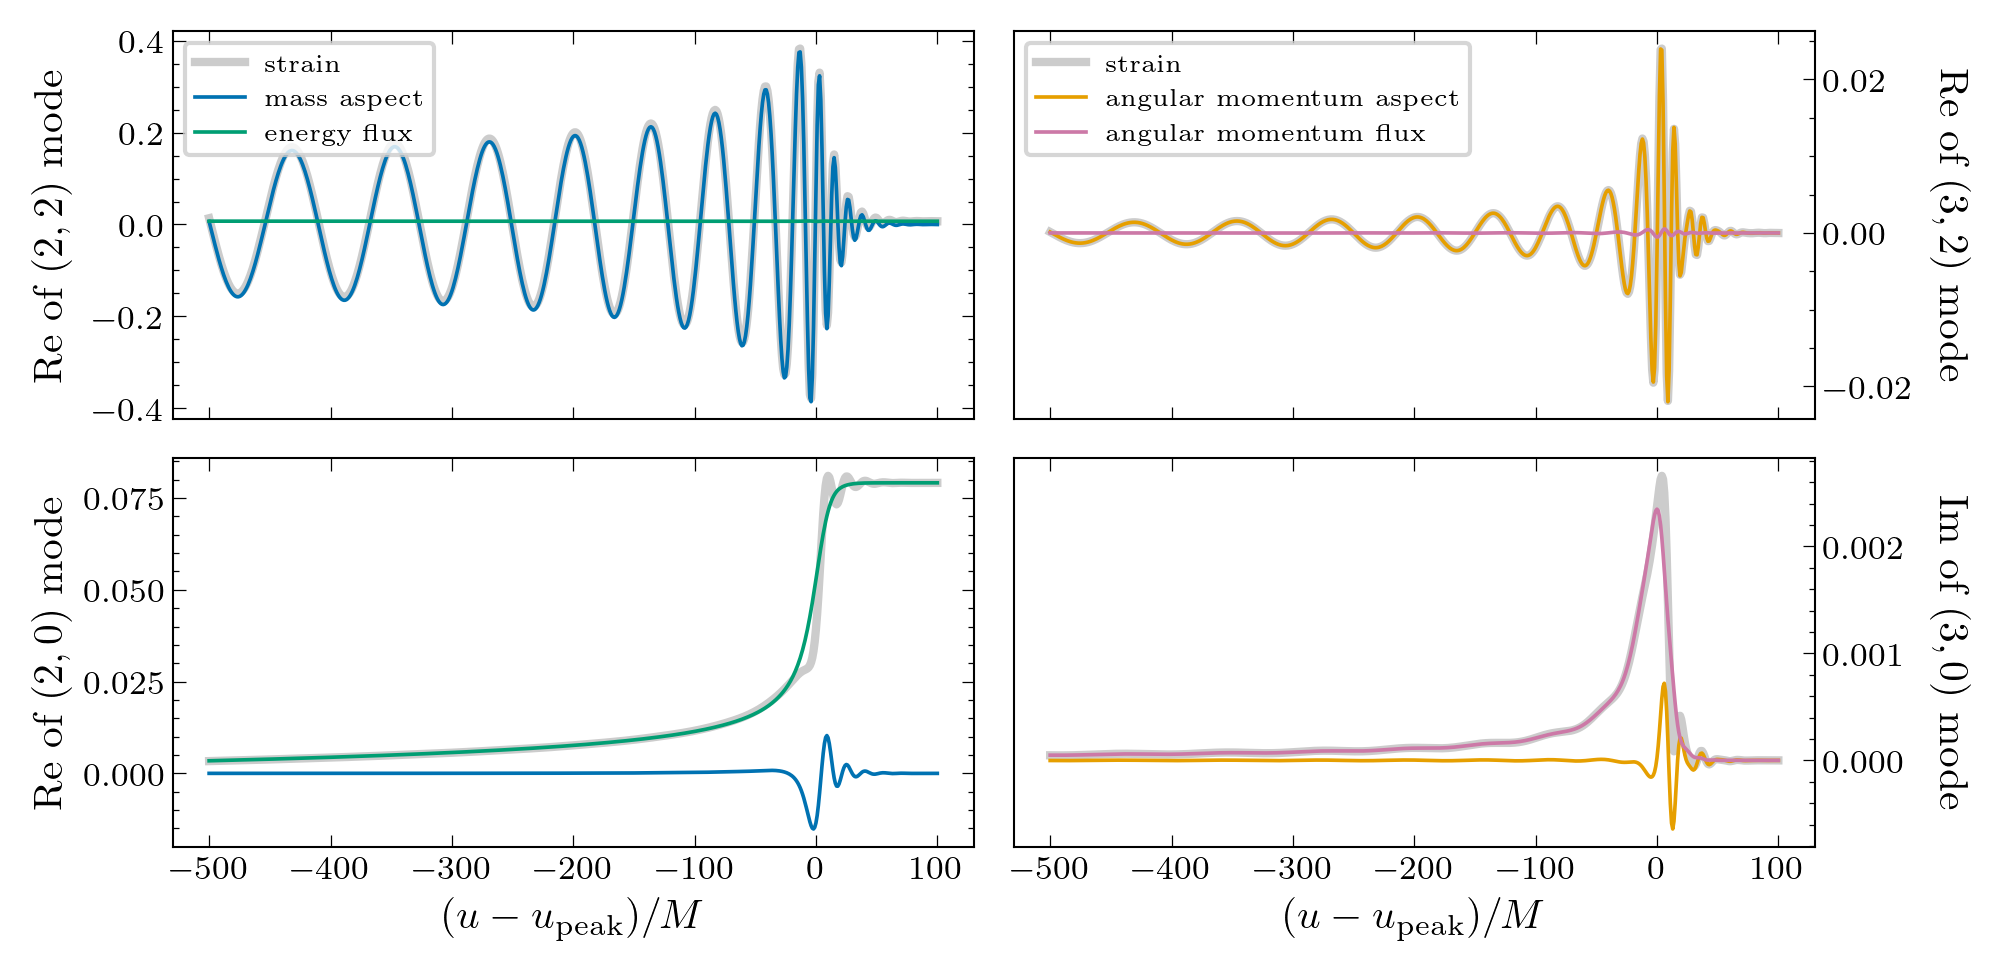

In [9]:
fig, axis = plt.subplots(2, 2, figsize=(twocol_w_in, twocol_w_in * 0.5), sharex=True)
plt.subplots_adjust(hspace=0.1, wspace=0.05)

idx1 = np.argmin(abs(h.t - -500))
idx2 = np.argmin(abs(h.t - 100)) + 1

L = 2; M = 2;
axis[0][0].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L,M)], lw=2, alpha=0.2, label='strain', color=colors[0])
axis[0][0].plot(h.t[idx1:idx2], h_m.data[idx1:idx2,h.index(L,M)], label='mass aspect', color=colors[1], lw=0.88)
axis[0][0].plot(h.t[idx1:idx2], h_E.data[idx1:idx2,h.index(L,M)], label='energy flux', color=colors[2], lw=0.88)
axis[0][0].legend(frameon=True, loc='upper left')

L = 3; M = 2;
axis[0][1].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L,M)], lw=2, alpha=0.2, label='strain', color=colors[0])
axis[0][1].plot(h.t[idx1:idx2], h_N.data[idx1:idx2,h.index(L,M)], label='angular momentum aspect', color=colors[3], lw=0.88)
axis[0][1].plot(h.t[idx1:idx2], h_J.data[idx1:idx2,h.index(L,M)], label='angular momentum flux', color=colors[4], lw=0.88)
axis[0][1].legend(frameon=True, loc='upper left')

axis[0][1].yaxis.set_label_position("right")
axis[0][1].yaxis.tick_right()

L = 2; M = 0;
axis[1][0].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L, M)], lw=2, alpha=0.2, label='strain', color=colors[0])
axis[1][0].plot(h.t[idx1:idx2], h_m.data[idx1:idx2,h.index(L,M)], label='mass aspect', color=colors[1], lw=0.88)
axis[1][0].plot(h.t[idx1:idx2], h_E.data[idx1:idx2,h.index(L,M)], label='energy flux', color=colors[2], lw=0.88)

L = 3; M = 0;
axis[1][1].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L,M)].imag, lw=2, alpha=0.2, label='strain', color=colors[0])
axis[1][1].plot(h.t[idx1:idx2], h_N.data[idx1:idx2,h.index(L,M)].imag, label='angular momentum aspect', color=colors[3], lw=0.88)
axis[1][1].plot(h.t[idx1:idx2], h_J.data[idx1:idx2,h.index(L,M)].imag, label='angular momentum flux', color=colors[4], lw=0.88)

axis[1][1].yaxis.set_label_position("right")
axis[1][1].yaxis.tick_right()

axis[1][0].set_xlabel(r'$(u-u_{\mathrm{peak}})/M$')
axis[1][1].set_xlabel(r'$(u-u_{\mathrm{peak}})/M$')
axis[0][0].set_ylabel(r'Re of $(2,2)$ mode')
axis[0][1].set_ylabel(r'Re of $(3,2)$ mode', rotation=270, labelpad=14)
axis[1][0].set_ylabel(r'Re of $(2,0)$ mode')
axis[1][1].set_ylabel(r'Im of $(3,0)$ mode', rotation=270, labelpad=14)
fig.align_ylabels();

Aha! With the strain in terms of the BMS charges and fluxes for a few spin-weight -2 spherical harmonics modes, we can start to see some recognizable phenomena. In particular, for the (2,2) mode, we see that the strain is sources by the Bondi mass aspect $\hat{m}$, which is really nothing more than a statement of the usual quadrupole formula. Meanwhile, for the (3,2) mode, which is a magnetic parity mode, we see that the strain is sourced by the angular momentum aspect $\hat{N}$, which is really nothing more than a statement of the current multipole formula.

But what's this funny $(2,0)$ mode doing? In this mode we see that the strain is sourced by both the Bondi mass aspect, but also the energy flux. And, in particular, the energy flux sources some nonzero net change in the strain. But what is this nonzero net change? It's the memory effect! Specifically the null memory effect. (A net change in the mass aspect is called the ordinary memory and happens for hyperbolic black hole encounters; this is how the memory effect was originally discovered by Zeldovich and Polnarev in the 1970s).

### Obtaining remnant parameters from Poincaré charges

Another incredibly useful feature of the BMS charges, or even just the Poincaré charges, is that we can use them to measure properties of the spacetime.

For example, normally if we wanted to know the mass and spin of the remnant black hole, we would have to resort to looking at quasi-local measurements on the apparent horizon of the remnant black hole, which are subject to the infinite number of gauge choices one can make for the bulk spacetime. These measurements are provided by our `metadata`:

In [10]:
import json

In [11]:
with open(f'{simulation}/metadata.json') as input_file:
    metadata = json.load(input_file)
print("remnant mass =", np.round(metadata["remnant_mass"], 3))
print("remnant spin vector =", np.round(metadata["remnant_dimensionless_spin"], 3))

remnant mass = 0.952
remnant spin vector = [0.    0.    0.686]


However, from the Poincaré charges, we can also measure the mass and the spin of the spacetime at null infinity, which at sufficiently late times should correspond to the mass and spin of the remnant. The exact form of the Poincaré charges can be found in Eqs. (4.8) of [arXiv:2405.08868](https://arxiv.org/abs/2405.08868) (see also Eq. (7.1), (7.4), and (7.6) of the same paper for some more useful charge definitions). But computing them from our `ABD` object, at least those which correspond to the remnant mass and spin, is as straightforward as:

In [12]:
remnant_mass = abd.bondi_rest_mass()[-1] #here -1 grabs the last time sample in the simulation, i.e., a late time
remnant_spin = abd.bondi_dimensionless_spin()[-1]
print("remnant mass =", np.round(remnant_mass, 3))
print("remnant spin vector =", np.round(remnant_spin, 3))

remnant mass = 0.952
remnant spin vector = [0.    0.    0.686]


Look at that! They're the same as above! (Note though if you expanded these to higher decimal places you would start to see differences).

### Doing (or trying to do) black hole perturbation theory

Continuing on with the discussion of the remnant black hole, let's try to do some perturbation theory.


<img src="images/perturbed_spacetime.png" align="right" width="600" height="200">

In particular, let's try to model the final stage of the BBH coalescence---the *ringdown*---with quasi-normal modes (QNMs).

As you may already know, first order black hole perturbation theory tells us that the gravitational wave strain can be modeled as a sum of damped sinusoids of the form
\begin{align}
h(t,\theta,\phi) = \sum\limits_{\ell,m,n,p}A_{(\ell,m,n,p)}\exp\left(-i\omega_{(\ell,m,n,p)}t\right)\phantom{}_{-2}S_{(\ell,m)}\left(a\omega_{(\ell,m,n,p)}\right)\left(\theta,\phi\right)
\end{align}
where
* $\ell,m$ are the usual angular indices,
* $n$ is the *overtone index* which higher $n$ corresponding to faster decaying tones,
* $p$ is the *prograde/retrograde* index, which represents if the tone is co-rotating or counter-rotating with the black hole,
* $A$ is a complex amplitude that depends on the nature of the perturbation,
* $\omega$ is the complex QNM frequency, which depends only on the remnant's mass and spin,
* and $\phantom{}_{-2}S_{(\ell,m)}\left(a\omega_{(\ell,m,n,p)}\right)\left(\theta,\phi\right)$ is the spin-weight -2 *spheroidal*-harmonic, which depends on the oblateness parameter $a\omega_{(\ell,m,n,p)}$ for $a$ the spin of the black hole.

One important note regarding this QNM representation is the the imaginary part of the QNM frequency is always negative, so the radiation always "damps" (this is why they're called "quasi-normal" modes; if they didn't decay, they would just be "normal" modes). But it's also important to remember that QNMs are not the only contribution to the strain during the ringdown!

Apart from the QNMs, we also expect a contribution known as the *prompt response* which you can loosely think of as the part of the perturbation that propagates directly to the observer as well as *power law tails* which are sourced by the outgoing radiation backscattering off of the curved geometry sourced by the black hole. However, the prompt response is challenging (if not impossible) to compute so we typically don't try to include it in ringdown analyses and the power law tails are largely subdominant so we also don't include them (note though that they do increase with increasing eccentricity, so they will be more relevant for high-eccentricy BBHs).

Now, for studying the gravitational wave emitted by a binary black hole, we have no idea *a prior* what the QNM amplitudes should be, as we don't know what the source of the perturbation to the remnant is. Nonetheless, the beauty of QNMs is that because of how the free parameters in the above equation are only the amplitudes (if you assume some fixed mass and spin; we'll discuss what happens later if you don't assume this), then one can easily find the best fitting QNM description by performing a linear least squares analysis.

For doing this fit, we'll use a part of the `qnmfinder` package:

In [13]:
import qnmfinder
from qnmfinder import ringdown, model, plotting, utils

First, we define a "QNM model" that we're going to fit, e.g., the $(2,2)$ fundamental $n=0$ and the first overtone (both prograde)

In [14]:
QNM_model = ringdown.QNMModel(
    remnant_mass,
    np.linalg.norm(remnant_spin),
    [
        ringdown.QNM((2,2,0,1)),
        ringdown.QNM((2,2,1,1)),
    ]
)

Then we fit it to our waveform at some start time `t_0`:

In [15]:
# we'll select just the part of the waveform relevant to the ringdown phase
h_to_fit = h[np.argmin(abs(h.t - -10)):np.argmin(abs(h.t - 100)) + 1]

In [16]:
t_0 = 20
fit_QNM_model = QNM_model.fit(h_to_fit, [(2,2)], t_0)

print("QNM amplitudes")
for QNM in fit_QNM_model.QNMs:
    print(QNM.mode, QNM.A)

QNM amplitudes
(2, 2, 0, 1) (-0.3272586843127767+0.46015065499010543j)
(2, 2, 1, 1) (3.017393299485101-0.9747349182758505j)


We can compute the QNM waveform (i.e., summing the amplitudes, multiply by the complex exponential, and accounting for spherical-spheroidal mixing) as:

In [17]:
h_QNM = fit_QNM_model.compute_waveform(h_to_fit)

and plot them!

/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


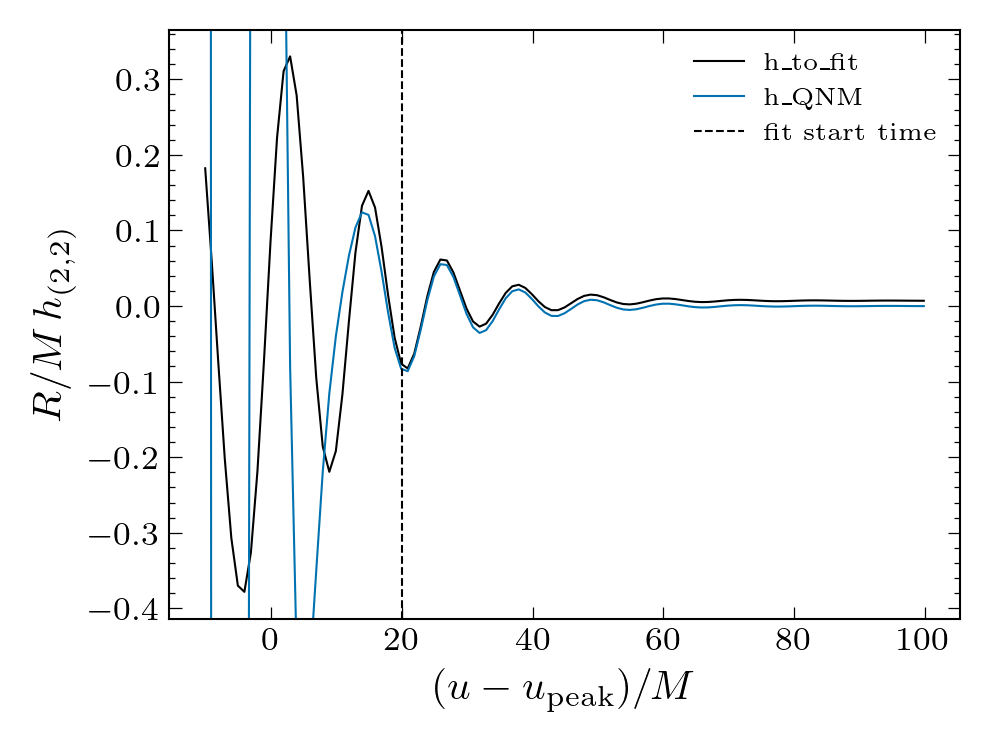

In [18]:
plt.plot(h_to_fit.t, h_to_fit.data[:,h_to_fit.index(2,2)], label='h_to_fit')
ylim = plt.ylim()
plt.plot(h_QNM.t, h_QNM.data[:,h_QNM.index(2,2)], label='h_QNM')
plt.ylim(ylim)
plt.axvline(t_0, ls='--', label='fit start time')
plt.legend(loc='upper right')
plt.xlabel(r'$(u-u_{\mathrm{peak}})/M$')
plt.ylabel(r'$R/M\,h_{(2,2)}$');

Not bad! But the two clearly disagree at late times: the QNMs model decays to zero, but the NR waveform doesn't... what's going on?

### Fixing the BMS frame

At the very beginning of this tutorial, we spent a fair amount of time discussing the *coordinate freedom* at future null infinity, which is described by the BMS group. However, we kind of side-stepped the issue that, if we have coordinate freedom, **we have to specify our coordinates!** In fact, it turns out that what's going on in the comparison between NR and QNMs above is that black hold perturbation theory is performed in a coordinate system which is different from the coordinate system of our NR simulation! So, if we want to meaningfully fit QNMs to NR, we need to fix this inconsistency, i.e., **we need to fix the BMS freedoms that our NR waveform is subject to**.

Doing this is known as *BMS frame fixing* and is well-understood. In particular, if I want to fix the coordinates of my NR system to match that of black hole perturbation theory, I need to look at the various (infinite) BMS charges of my NR simulation and chance my coordinates such that my charges match that of black hole perturbation theory. E.g., if the remnant black hole in my NR simulation is moving with some velocity, I can see that by looking at the center-of-mass charge; and, I can then remove this center-of-mass motion by Lorentz boosting my NR simulation so that the remnant is no longer moving and is instead stationary at the origin, like the black hole used when performing black hole perturbation theory. Fortunately, doing this whole analysis is already coded up as a part of the `ABD` object! So let's fix the BMS frame.

First, we'll restrict our `ABD` object to the ringdown to speed up the computation:

In [19]:
abd_ring = abd_raw.interpolate(np.arange(-10, 80, 1.0))

Then, we'll fix the frame by mapping the BMS charges to the values expected by black hole perturbation theory using some time window, defined by central `t_0` time and some `padding_time` around it:

In [20]:
# this will take ~1 minute
abd_ring_fixed, BMS_transformation, _ = abd_ring.map_to_superrest_frame(t_0=80, padding_time=10)

To see the impact of this transformation, let's look at the $(2,0)$ mode of the strain. Remember that this mode has memory, so based on what we saw above in our original frame it should be a large, nonzero value at late times.

In [21]:
h_ring = abd_ring.h
h_ring_fixed = abd_ring_fixed.h

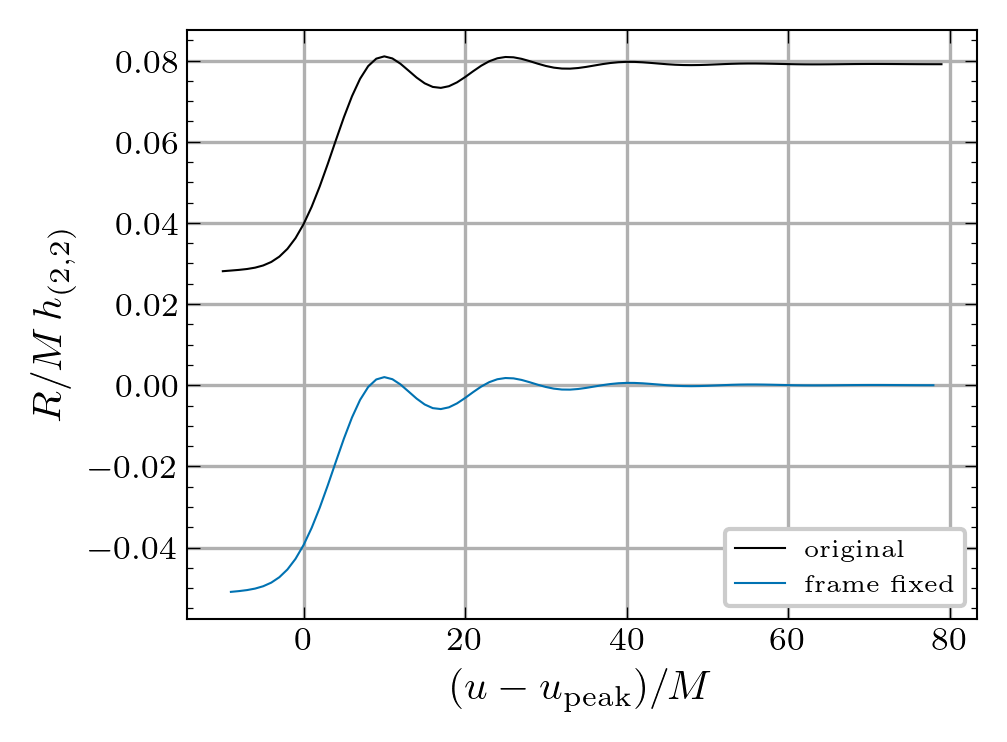

In [22]:
L = 2; M = 0;
plt.plot(h_ring.t, h_ring.data[:,h_ring.index(L,M)], label='original')
plt.plot(h_ring_fixed.t, h_ring_fixed.data[:,h_ring_fixed.index(L,M)], label='frame fixed')
plt.legend(loc='lower right', frameon=True, framealpha=1)
plt.grid()
plt.xlabel(r'$(u-u_{\mathrm{peak}})/M$')
plt.ylabel(r'$R/M\,h_{(2,2)}$');

Wow! After fixing the frame of our `ABD` object, we now see that our strain decays to exactly zero at late times, in agreement with perturbation theory!

So what happens if we repeat our QNM fitting from earlier?

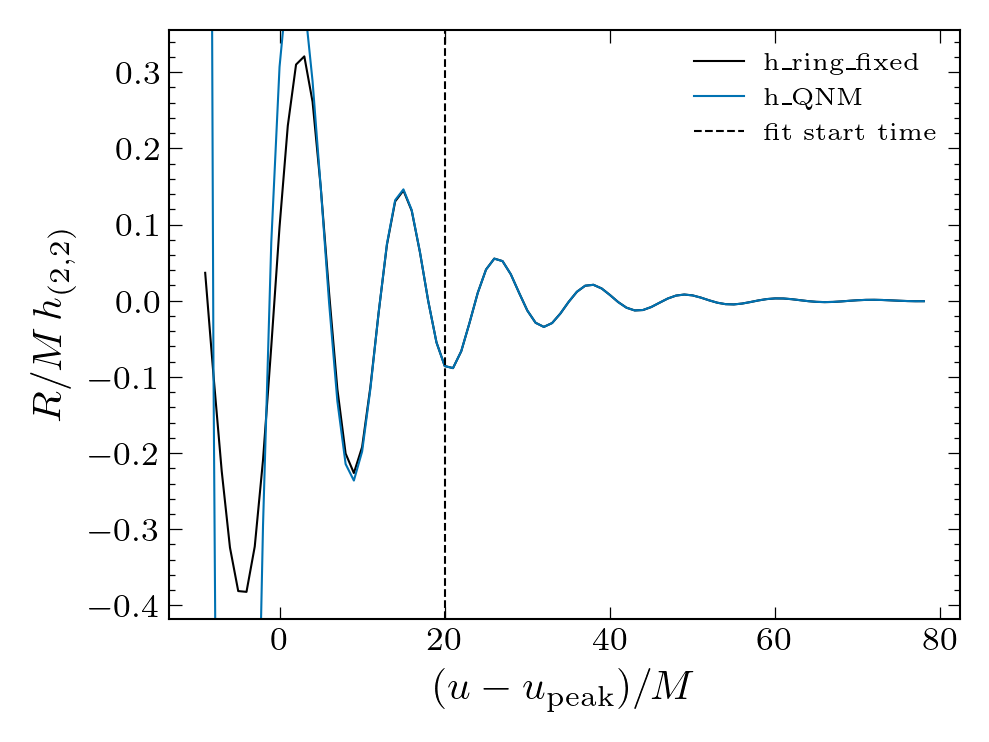

In [23]:
t_0 = 20
fit_QNM_model = QNM_model.fit(h_ring_fixed, [(2,2)], t_0)

h_QNM = fit_QNM_model.compute_waveform(h_ring_fixed)

plt.plot(h_ring_fixed.t, h_ring_fixed.data[:,h_ring_fixed.index(2,2)], label='h_ring_fixed')
ylim = plt.ylim()
plt.plot(h_QNM.t, h_QNM.data[:,h_QNM.index(2,2)], label='h_QNM')
plt.ylim(ylim)
plt.axvline(t_0, ls='--', label='fit start time')
plt.legend(loc='upper right')
plt.xlabel(r'$(u-u_{\mathrm{peak}})/M$')
plt.ylabel(r'$R/M\,h_{(2,2)}$');

Incredible! This is much better.

### Fitting QNMs to NR

So now that we have a deeper understanding of BMS frame fixing and how to correctly do black hole perturbation theory analyses with NR waveforms, what else can we do?

Well thus far we've only done a naive fit to the $(2,2)$ mode only, but we could easily fit more spherical-harmonics modes and do so simultaneously!

In fact, this is as easy as adding other QNMs to our QNM model, and including more modes in out fit via:

In [24]:
QNM_model = ringdown.QNMModel(
    remnant_mass,
    np.linalg.norm(remnant_spin),
    [
        ringdown.QNM((2,2,0,1)),
        ringdown.QNM((2,2,1,1)),
        ringdown.QNM((2,0,0,1)),
        ringdown.QNM((2,0,0,-1)),
        ringdown.QNM((3,2,0,1)),
        ringdown.QNM((4,4,0,1)),
    ]
)

(⭐️ Bonus: why do we need both the prograde $p=1$ and retrograde $p=-1$ QNMs for the $(2,0)$ mode?)

<details>
  <summary>Answer!</summary>
  
  Because the $(2,0)$ mode is an $m=0$ mode, and we have no "$\exp(im\phi)$" term in the expansion of the strain, it is simultaneously co-rotating and counter-rotating, hence why we need both!
</details>

In [25]:
t_0 = 20
fit_QNM_model = QNM_model.fit(h_ring_fixed, None, t_0)

h_QNM = fit_QNM_model.compute_waveform(h_ring_fixed)

Text(0.5, 0, '$(u-u_{\\mathrm{peak}})/M$')

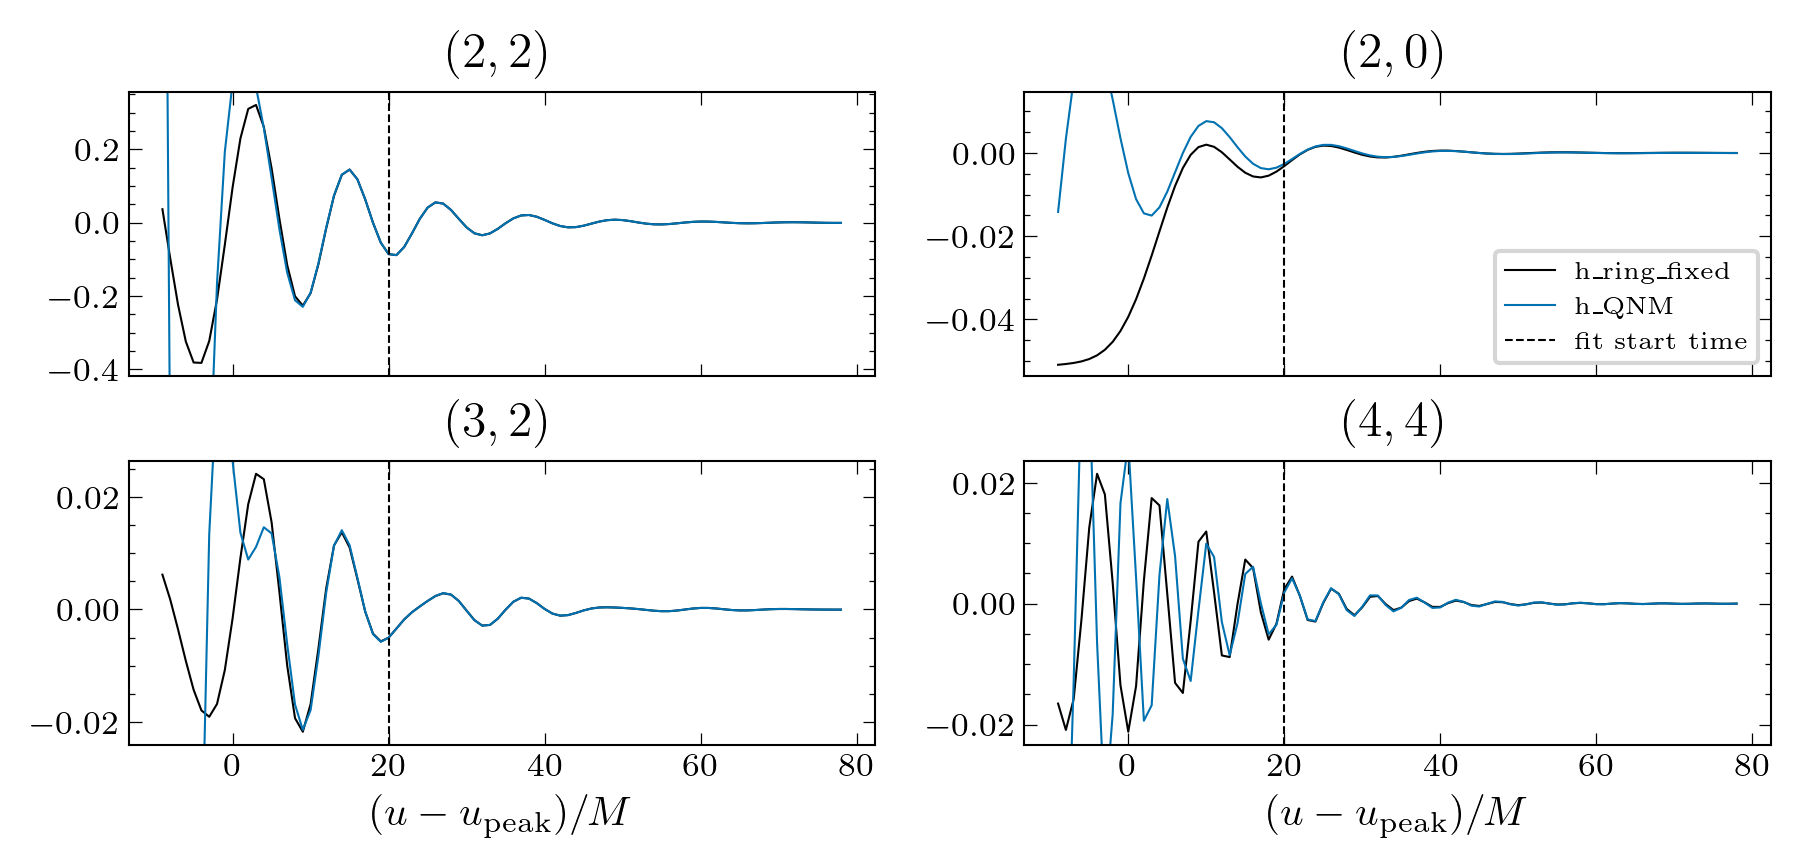

In [26]:
fig, axis = plt.subplots(2, 2, figsize=(twocol_w_in, 0.4 * twocol_w_in), sharex=True)
plt.subplots_adjust(hspace=0.3)
modes = [(2,2), (2,0), (3,2), (4,4)]

for i, mode in enumerate(modes):
    idx1 = i//2; idx2 = i%2;
    axis[idx1][idx2].plot(h_ring_fixed.t, h_ring_fixed.data[:,h_ring_fixed.index(mode[0],mode[1])], label='h_ring_fixed')
    ylim = axis[idx1][idx2].get_ylim()
    axis[idx1][idx2].plot(h_QNM.t, h_QNM.data[:,h_QNM.index(mode[0],mode[1])], label='h_QNM')
    if mode == (2,0):
        ylim = (ylim[0], ylim[1] + 0.01)
    axis[idx1][idx2].set_ylim(ylim)
    axis[idx1][idx2].axvline(t_0, ls='--', label='fit start time')
    axis[idx1][idx2].set_title(r'$(' + str(mode[0]) + ',' + str(mode[1]) + ')$')
axis[0][1].legend(loc='lower right', frameon=True)
axis[1][0].set_xlabel(r'$(u-u_{\mathrm{peak}})/M$')
axis[1][1].set_xlabel(r'$(u-u_{\mathrm{peak}})/M$')

Cool! But how do we know we're actually fitting QNMs that are in the data? I.e., how do we know that we're not *overfitting* the data?

Unfortunately, the answer to this is not obvious and has been the subject of much debate in the community. However, one somewhat reasonable approach for building of a set of QNMs that one should to fit to an NR waveform (but certainly not the only reasonable approach) is the following:
* Use a nonlinear fitting scheme to fit for some free frequency which best fits the least well-modeled mode of the NR waveform
* Check to see if that frequency matches a QNM frequency (within some tolerance)
* If it does, check to see if we obtain consistent predictions for the QNM amplitude across varying fit start times
* If it does, add it to the model
* Repeat!

This algorithm was presented in [arXiv:2503.09678](https://arxiv.org/abs/2503.09678) and can also be run using the `qnmfinder` package.

In more detail, it is described by the following diagram:

<img src="images/qnmfinder_algorithm.png" align="center" width="800" height="200">

Let's watch it go to work!

In [27]:
QNM_model_builder = model.QNMModelBuilder(
    h_ring_fixed, 1.0, remnant_mass, np.linalg.norm(remnant_spin), t_i=0, t_0_f=60, d_t_0=1.0, d_t_0_search=2.0, t_f=100,
    N_free_frequencies_max=2, CV_tolerance=2e-1, min_t_0_window_factor=100.0, ell_max_NR=4,
    fit_news=True, n_procs=-1, verbose=True,
    t_peak_norm_function='strain'
)
QNM_model_builder.build_model()

***************
Building Model!
***************

* t_i = 0
* t_f = 100
* t_0_f = 60
* t_peak_norm_function = strain
* d_t_0 = 1.0
* d_t_0_search = 2.0
* fit_news = True
* include_2nd_order_QNMs = True
* include_3rd_order_QNMs = False
* N_free_frequencies_max = 2
* power_tolerance = 1e-12
* CV_tolerance = 0.2
* min_t_0_window_factor = 100.0
* min_A_tolerance = 1e-12

** working on t_0 = 60.

** modeling (np.int64(2), np.int64(-2))
* top four power rankings :
- [ 2 -2] -> 2.4297323556890795e-06
- [2 2] -> 2.429732351486127e-06
- [ 3 -2] -> 1.57738415210005e-08
- [3 2] -> 1.577384124901666e-08

* (2, -2, 0, -1) matched to frequency, d_omega = 0.0004

** model passed stability test!
* new window(s):
(2, -2, 0, -1) -> (np.float64(5.0), np.float64(59.0))
* new CV(s):

(2, -2, 0, -1) -> 0.15197000609726052
** new model is
- (2, -2, 0, -1)

* examining mirror mode(s):
- (2, 2, 0, 1)
** model passed stability test!
* new window(s):
(2, 2, 0, 1) -> (np.float64(5.0), np.float64(59.0))
* new CV(s)

So what QNMs did it find?

In [28]:
for QNM in QNM_model_builder.QNM_model.QNMs:
    print(QNM.mode)

(2, -2, 0, -1)
(2, 2, 0, 1)
(3, 2, 0, 1)
(3, -2, 0, -1)
(4, -4, 0, -1)
[(2, -2, 0, -1), (2, -2, 0, -1)]
(4, 4, 0, 1)
[(2, 2, 0, 1), (2, 2, 0, 1)]
(2, -2, 1, -1)
(2, -2, 2, -1)
(2, 2, 1, 1)
(2, 2, 2, 1)
(2, 0, 0, -1)
(2, 0, 0, 1)


Wow, that's a lot! And what's that $[(2,2,0,1),(2,2,0,1)]$ mode?

<details>
  <summary>Answer!</summary>
  
  It's the *quadratic QNM*! I.e., the nonlinear excitation of a tone predicted by second-order black hole perturbation theory (see [arXiv:2208.07380](https://arxiv.org/abs/2208.07380) for more details!)
</details>

We can also check where the algorithm thought the QNMs had amplitude measurements that we're the most consistent (or most stable) across different fit start times via

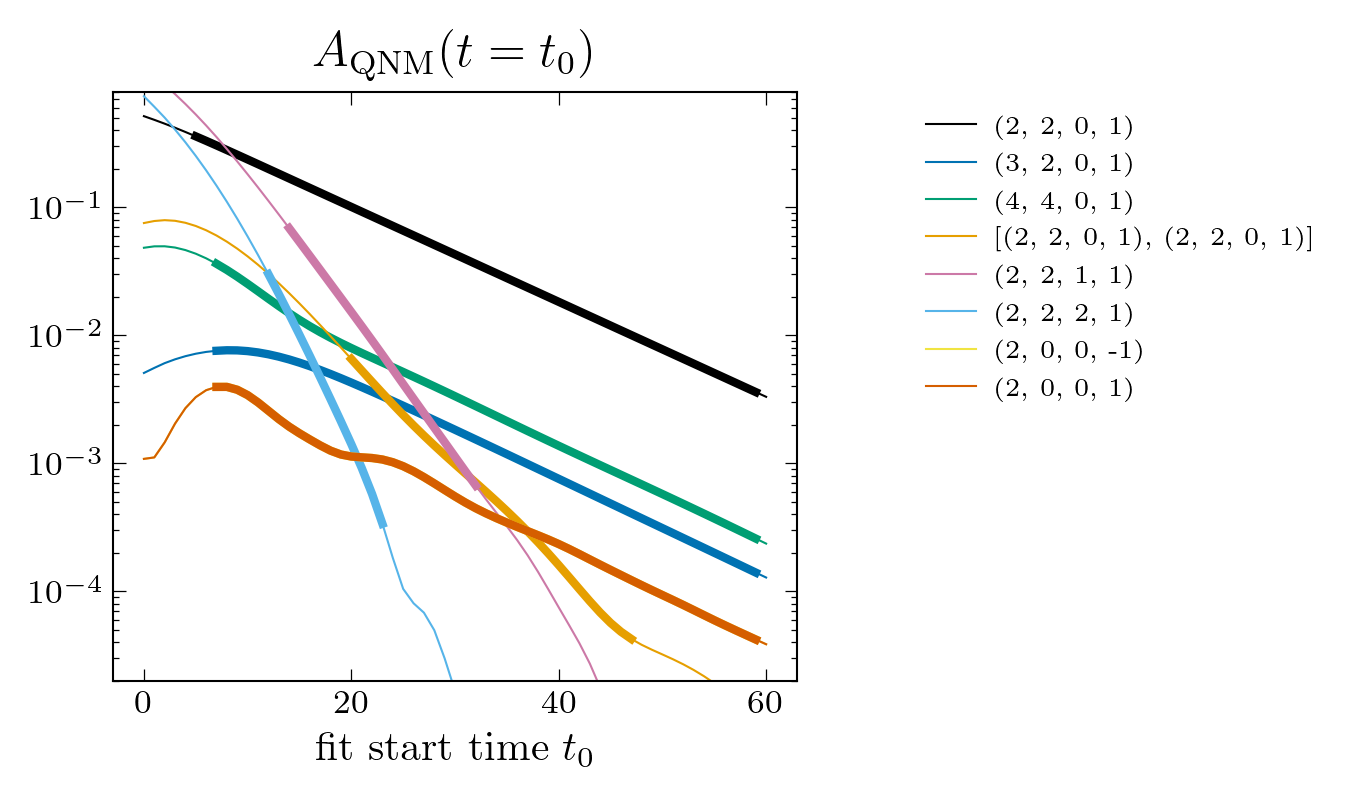

In [29]:
plotting.plot_amplitudes_and_phases(QNM_model_builder.QNM_model, plot_phases=False, vert_limits=(2e-5, 0.8))

### Finding the remnant mass and spin from QNMs

Another experiment that people often run with QNMs is to check how well the QNM model enables one to measure the mass and spin of the remnant black hole.

To do this, we'll want to fit the data with our QNM model, but leave the mass and spin as free parameters.

Fortunately, we can easily do this using `scipy`'s `optimize` module.

In [30]:
from scipy.optimize import minimize

First, we'll define the function that we want to minimize:

In [31]:
# this simply fits the QNM model and returns the L2 norm of the residual between the fit and the NR waveform
def func_to_minimize(x, h_to_fit, QNM_model, t_0, modes):
    remnant_mass, remnant_spin = x
    
    QNM_model.M_f = remnant_mass
    QNM_model.chi_f = remnant_spin
    fit_QNM_model = QNM_model.fit(h_to_fit, modes, t_0)

    h_QNM = fit_QNM_model.compute_waveform(h_to_fit)

    L2_norm = utils.compute_L2_norm(
        h_to_fit, h_QNM, t_i=t_0, t_f=100, modes=modes
    )

    return L2_norm

Then we'll choose some initial mass and spin values and try doing the opitmization!

In [32]:
x0 = (0.5, 0.5); t_0 = 20;
args = (h_ring_fixed, QNM_model_builder.QNM_model, t_0, None)
res = minimize(func_to_minimize, x0, args, method='L-BFGS-B', bounds=((0.0, 1.0), (0.0, 0.9999)))

print("remnant mass =", remnant_mass)
print("fit remnant mass=", res.x[0])
print("")
print("remnant spin =", np.linalg.norm(remnant_spin))
print("fit remnant spin=", res.x[1])

remnant mass = 0.9516192580090734
fit remnant mass= 0.9511644202627461

remnant spin = 0.6864419211233544
fit remnant spin= 0.6858336826301576


Not bad! The QNM model we obtained from our algorithm indeed seems to prefer a remnant mass and spin that agrees with the Poincaré charges to three decimal places!

### Fitting QNMs to GW150914

To fit to real LVK observations, we need a time-domain inference code.

Fortunately, such a code exists and is publicly available through the [ringdown package](https://github.com/maxisi/ringdown/blob/main/docs/examples/GW150914.ipynb).

Let's check it out to see how we can analyze GW150914!